In [1]:
# ==============================================================================
# CELL 1: HARDWARE & ENVIRONMENT INITIALIZATION
# ==============================================================================
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
from sklearn.metrics import roc_auc_score
import warnings

# Suppress PyTorch warnings for cleaner stdout
warnings.filterwarnings("ignore", category=UserWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[SYSTEM] Computation hardware initialized -> {device}")

[SYSTEM] Computation hardware initialized -> cuda


In [2]:


class WSIFeatureDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        
        # The **/*.pt recursively hunts down every tensor across all 7 internal folders
        self.raw_files = list(Path(root_dir).glob('**/*.pt'))
        self.valid_files = []
        self.labels = []
        
        print(f"[PRE-FLIGHT] Scanning {root_dir} for tensors...")
        
        # Pre-flight check: physically test each tensor and assign labels
        for file_path in self.raw_files:
            try:
                # 1. Integrity Check: Can PyTorch read it without crashing?
                _ = torch.load(file_path, weights_only=True)
                
                # 2. Label Assignment: Check if 'tumor' or 'normal' is in the file path
                path_str = str(file_path).lower()
                if 'tumor' in path_str:
                    label = 1
                elif 'normal' in path_str:
                    label = 0
                else:
                    continue 
                    
                self.valid_files.append(file_path)
                self.labels.append(label)
                
            except Exception as e:
                print(f"[WARNING] Corrupted file isolated and skipped: {file_path.name}")
                
        print(f"[DATA] Pre-flight complete. {len(self.valid_files)} healthy tensors locked.")
        
        tumor_count = sum(self.labels)
        normal_count = len(self.labels) - tumor_count
        print(f"[CLASS DISTRIBUTION] Normal (0): {normal_count} | Tumor (1): {tumor_count}")

    def __len__(self):
        return len(self.valid_files)

    def __getitem__(self, idx):
        file_path = self.valid_files[idx]
        label = self.labels[idx]
        
        features = torch.load(file_path, weights_only=True)
        
        if features.dim() > 2:
            features = features.squeeze(0)
            
        features = features.type(torch.float32)
        
        return features, torch.tensor(label, dtype=torch.float32)
# ==========================================
# EXECUTION
# ==========================================
from torch.utils.data import random_split


DATASET_PATH = '/kaggle/input/datasets/vanshdistsys2/gigapix-abmil-features/gigapix-abmil features' 

# 2. Initialize the master dataset
master_dataset = WSIFeatureDataset(root_dir=DATASET_PATH)

# 3. Create the 80/20 Train/Validation Split
train_size = int(0.8 * len(master_dataset))
val_size = len(master_dataset) - train_size

train_dataset, val_dataset = random_split(master_dataset, [train_size, val_size])
print(f"[SPLIT] Training on {train_size} slides | Validating on {val_size} slides")

# 4. Initialize BOTH DataLoaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=1, 
    shuffle=True, 
    num_workers=2, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=1, 
    shuffle=False, # No need to shuffle validation data
    num_workers=2, 
    pin_memory=True
)

[PRE-FLIGHT] Scanning /kaggle/input/datasets/vanshdistsys2/gigapix-abmil-features/gigapix-abmil features for tensors...
[DATA] Pre-flight complete. 269 healthy tensors locked.
[CLASS DISTRIBUTION] Normal (0): 159 | Tumor (1): 110
[SPLIT] Training on 215 slides | Validating on 54 slides


In [3]:
# ==============================================================================
# CELL 3: ATTENTION-BASED MIL ARCHITECTURE (768d)
# ==============================================================================
class GatedAttention(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256):
        super(GatedAttention, self).__init__()
        # Evaluates non-linear patch relations
        self.attention_V = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.Tanh())
        # Sigmoid gate prevents gradient explosion across massive slide bags
        self.attention_U = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.Sigmoid())
        self.attention_weights = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        A_V = self.attention_V(x)  
        A_U = self.attention_U(x)  
        A = self.attention_weights(A_V * A_U)  
        A = torch.softmax(A, dim=0)            
        M = torch.mm(A.t(), x)                 
        return M, A

class GigapixelABMIL(nn.Module):
    def __init__(self, input_dim=768):
        super(GigapixelABMIL, self).__init__()
        self.attention_module = GatedAttention(input_dim=input_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        M, A = self.attention_module(x)  
        logits = self.classifier(M) 
        return logits, A

# Instantiate Topology
model = GigapixelABMIL(input_dim=768).to(device)
criterion = nn.BCEWithLogitsLoss()
print("[MODEL] ABMIL Architecture compiled for 768d latent space.")

[MODEL] ABMIL Architecture compiled for 768d latent space.


In [4]:
# ==============================================================================
# CELL 4: TRAINING INFRASTRUCTURE & CALLBACKS
# ==============================================================================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"[CALLBACK] EarlyStopping observation {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

epochs = 100
optimizer = optim.Adam(model.parameters(), lr=0.00005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
early_stopper = EarlyStopping(patience=5)
print("[SETUP] Optimizers and callbacks configured.")

[SETUP] Optimizers and callbacks configured.


In [5]:
# ==============================================================================
# CELL 5: EXECUTION PIPELINE
# ==============================================================================
print("\n[TRAIN] Engaging optimization loop. Awaiting convergence...")

for epoch in range(epochs):
    epoch_start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0.0
    
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device).squeeze(0)
        batch_labels = batch_labels.to(device)
        
        optimizer.zero_grad()
        predictions, _ = model(batch_features)
        
        loss = criterion(predictions.view(-1), batch_labels.view(-1))
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)

   # ==========================
    # VALIDATION PHASE
    # ==========================
    model.eval()
    epoch_val_loss = 0.0
    val_preds_list = []
    val_labels_list = []

    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_features = val_features.to(device).squeeze(0)
            val_labels = val_labels.to(device)

            # Forward pass
            val_preds, _ = model(val_features)

            #
            batch_loss = criterion(val_preds.view(-1), val_labels.view(-1))
            epoch_val_loss += batch_loss.item()

            # Store predictions and labels for metric calculations (AUC)
            # We apply sigmoid here because BCEWithLogitsLoss outputs raw logits
            val_preds_list.extend(torch.sigmoid(val_preds).view(-1).cpu().numpy())
            val_labels_list.extend(val_labels.view(-1).cpu().numpy())

    # Calculate average validation loss for the epoch
    avg_val_loss = epoch_val_loss / len(val_loader)
    # --- METRICS COMPILATION ---
    val_predictions = [1 if p > 0.5 else 0 for p in val_preds_list]
    correct = sum(1 for p, l in zip(val_predictions, val_labels_list) if p == l)
    
    val_accuracy = (correct / len(val_loader)) * 100.0
    val_auc = roc_auc_score(val_labels_list, val_preds_list)
    
    epoch_duration = time.time() - epoch_start_time

    print(f"[EPOCH {epoch+1:02d}/{epochs}] "
          f"Time: {epoch_duration:.1f}s | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Acc: {val_accuracy:.2f}% | "
          f"AUC: {val_auc:.4f}")
    
    # --- STATE TRIGGERS ---
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    
    if new_lr < current_lr:
        print(f"[CALLBACK] Learning rate reduced to {new_lr:.2e}")
        
    early_stopper(avg_val_loss)
    if early_stopper.early_stop:
        print(f"[SYSTEM] Convergence criteria met. Halting to preserve generalization state.")
        break


[TRAIN] Engaging optimization loop. Awaiting convergence...
[EPOCH 01/100] Time: 88.8s | Train Loss: 0.6867 | Val Loss: 0.6836 | Acc: 59.26% | AUC: 0.4844
[EPOCH 02/100] Time: 68.1s | Train Loss: 0.6803 | Val Loss: 0.6800 | Acc: 59.26% | AUC: 0.4929
[EPOCH 03/100] Time: 74.0s | Train Loss: 0.6774 | Val Loss: 0.6784 | Acc: 59.26% | AUC: 0.5114
[EPOCH 04/100] Time: 66.3s | Train Loss: 0.6736 | Val Loss: 0.6774 | Acc: 59.26% | AUC: 0.5213
[EPOCH 05/100] Time: 75.6s | Train Loss: 0.6739 | Val Loss: 0.6770 | Acc: 59.26% | AUC: 0.5241
[EPOCH 06/100] Time: 74.5s | Train Loss: 0.6689 | Val Loss: 0.6748 | Acc: 59.26% | AUC: 0.5412
[EPOCH 07/100] Time: 69.9s | Train Loss: 0.6647 | Val Loss: 0.6735 | Acc: 59.26% | AUC: 0.5483
[EPOCH 08/100] Time: 74.7s | Train Loss: 0.6623 | Val Loss: 0.6692 | Acc: 55.56% | AUC: 0.5866
[EPOCH 09/100] Time: 77.0s | Train Loss: 0.6623 | Val Loss: 0.6660 | Acc: 55.56% | AUC: 0.5923
[EPOCH 10/100] Time: 79.3s | Train Loss: 0.6535 | Val Loss: 0.6603 | Acc: 55.56% | A


[SYSTEM] Generating Medical Evaluation Telemetry...


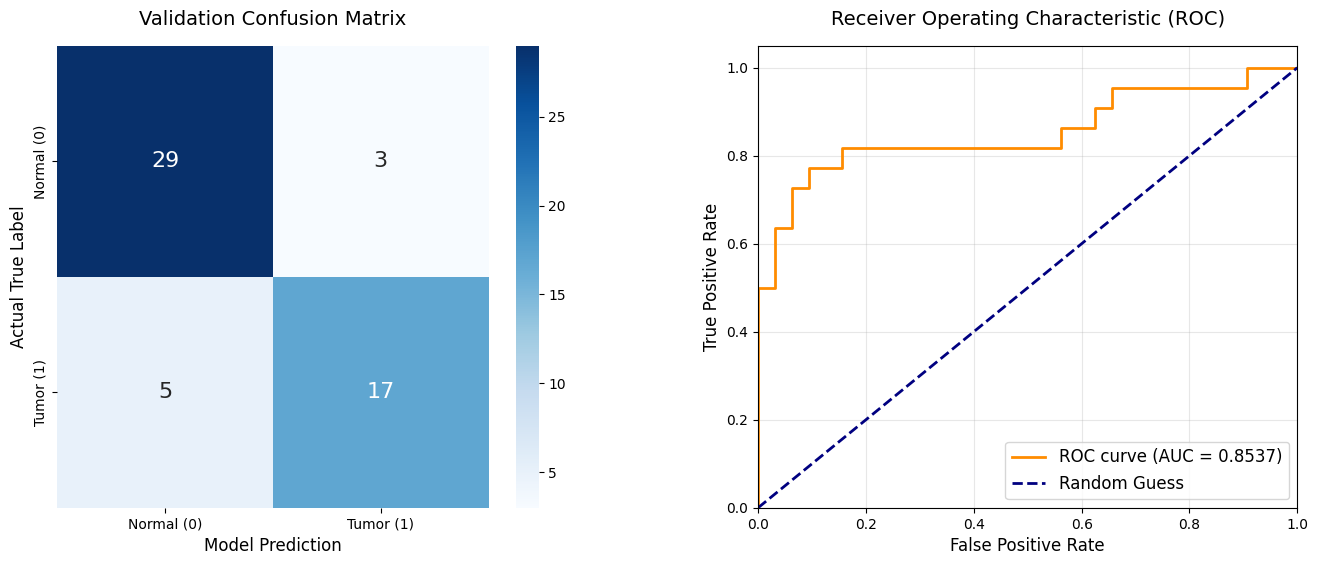

[SYSTEM] Telemetry successfully rendered.


In [6]:
# ==========================================
# CELL 6: MEDICAL EVALUATION METRICS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

def plot_medical_evaluation(labels, predictions):
    print("\n[SYSTEM] Generating Medical Evaluation Telemetry...")
    labels = np.array(labels)
    predictions = np.array(predictions)
    
    # Binarize predictions at 0.5 threshold
    binary_preds = (predictions >= 0.5).astype(int)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plt.subplots_adjust(wspace=0.3)

    # 1. CONFUSION MATRIX
    cm = confusion_matrix(labels, binary_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal (0)', 'Tumor (1)'], 
                yticklabels=['Normal (0)', 'Tumor (1)'],
                annot_kws={"size": 16})
    
    axes[0].set_title('Validation Confusion Matrix', fontsize=14, pad=15)
    axes[0].set_ylabel('Actual True Label', fontsize=12)
    axes[0].set_xlabel('Model Prediction', fontsize=12)

    # 2. ROC CURVE
    fpr, tpr, _ = roc_curve(labels, predictions)
    roc_auc = auc(fpr, tpr)
    
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
    
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=15)
    axes[1].legend(loc="lower right", fontsize=12)
    axes[1].grid(True, alpha=0.3)

    plt.show()
    print("[SYSTEM] Telemetry successfully rendered.")

# EXECUTION: Protected call to prevent pre-execution crashes
try:
    plot_medical_evaluation(val_labels_list, val_preds_list)
except NameError:
    print("[ERROR] Telemetry lists not found. Ensure Cell 5 (Training Loop) has completely finished running.")

In [7]:
# ==========================================
# CELL 7: MODEL WEIGHTS EXPORT
# ==========================================
import torch
import os

# Define the save path in Kaggle's persistent output directory
SAVE_PATH = '/kaggle/working/gigapixel_abmil_weights_v1.pth'

try:
    print("[SYSTEM] Initiating model export sequence...")
    
    # Extract the state dictionary (the learned weights and biases)
    # We move it to CPU first to ensure it can be loaded on machines without GPUs
    torch.save(model.cpu().state_dict(), SAVE_PATH)
    
    # Verify the file was created and check its footprint
    file_size_mb = os.path.getsize(SAVE_PATH) / (1024 * 1024)
    print(f"[SUCCESS] Model architecture securely exported to: {SAVE_PATH}")
    print(f"[DATA] Payload size: {file_size_mb:.2f} MB")
    print("\n[ACTION REQUIRED] Navigate to the 'Output' section on the right sidebar in Kaggle to download your .pth file.")
    
except Exception as e:
    print(f"[FATAL EXPORT ERROR] {e}")

[SYSTEM] Initiating model export sequence...
[SUCCESS] Model architecture securely exported to: /kaggle/working/gigapixel_abmil_weights_v1.pth
[DATA] Payload size: 3.26 MB

[ACTION REQUIRED] Navigate to the 'Output' section on the right sidebar in Kaggle to download your .pth file.
